In [1]:
import numpy as np
import parismc
import dynesty

In [ ]:
import os
import sys
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

In [3]:
# import time

def loglike(params):
    # start_time = time.time()
    params = np.asarray(params)

    n_samples = params.shape[0]
    # print(f'Processing {n_samples} samples')
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        # sample_start = time.time()
        # try:
        m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0 = params[i]
        phiK = phiS + np.pi/3

        # htemp_start = time.time()
        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        
        # htemp_end = time.time()
        # print(f'    Waveform generation time: {htemp_end - htemp_start:.4f}s')

        # loglike_start = time.time()
        res = data - htemp
        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        log_likes[i] = -0.5 * inner_res
            # loglike_end = time.time()
            # print(f'    Log-likelihood computation time: {loglike_end - loglike_start:.4f}s')

            # sample_end = time.time()
            # print(f'  Sample {i+1}/{n_samples}: {sample_end - sample_start:.4f}s')

        # except Exception as e:
        #     # sample_end = time.time()
        #     # print(f'  Sample {i+1}/{n_samples}: ERROR in {sample_end - sample_start:.4f}s - {e}')
        #     log_likes[i] = -np.inf

    # end_time = time.time()
    # print(f'Total batch time: {end_time - start_time:.4f}s')
    return log_likes


In [4]:
def prior_transform(u):
    m1lim = [9.9999999974e+05, 1.0000000003e+06]
    m2lim = [2.9999843364e+01, 3.0000156636e+01]
    alim = [6.9979859020e-01, 7.0020140980e-01]
    p0lim = [7.4988920111e+00, 7.5011079889e+00]
    e0lim = [3.9994752843e-01, 4.0005247157e-01]
    distlim = [2.8977461563e+00, 3.1022538437e+00]
    qSlim = [4.3330287321e-01, 5.6669712679e-01]
    phiSlim = [9.4376145549e-01, 1.0562385445e+00]
    Phiphilim = [3.5581490499e-01, 4.4418509501e-01]
    Phirlim = [4.7878057162e-01, 5.2121942838e-01]

    transformed = np.zeros_like(u)

    # Log-uniform for masses

    # m1
    transformed[:, 0] = 10**(np.log10(m1lim[0]) + u[:, 0] * (np.log10(m1lim[1]) - np.log10(m1lim[0])))

    # m2
    transformed[:, 1] = 10**(np.log10(m2lim[0]) + u[:, 1] * (np.log10(m2lim[1]) - np.log10(m2lim[0])))
    
    # Uniform for other parameters

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # dist 
    transformed[:, 5] = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]

    # qS
    transformed[:, 6] = (qSlim[1] - qSlim[0]) * u[:, 6] + qSlim[0]

    # phiS
    transformed[:, 7] = (phiSlim[1] - phiSlim[0]) * u[:, 7] + phiSlim[0]

    # Phi_phi0
    transformed[:, 8] = (Phiphilim[1] - Phiphilim[0]) * u[:, 8] + Phiphilim[0]

    # Phi_r0
    transformed[:, 9] = (Phirlim[1] - Phirlim[0]) * u[:, 9] + Phirlim[0]

    
    return transformed

In [24]:
paris_sampler = parismc.Sampler.load_state('./likelihoodtest_results/sampler_state.pkl')

In [31]:
def visualize_marginal_distributions(sampler, savepath, true_values=None):
    """
    Create marginal distribution plots for each dimension 
    """
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
    except ImportError:
        print("Matplotlib/seaborn not available. Skipping visualization.")
        return

    print("\nCreating marginal distribution plots...")

    # Get samples and weights
    samples, weights = sampler.get_samples_with_weights(flatten=True)
    ndim = samples.shape[1]

    param_ranges = [
        [9.9999999984e+05, 1.0000000002e+06], # m1
        [2.9999906018e+01, 3.0000093982e+01], # m2
        [6.9987915412e-01, 7.0012084588e-01], # a
        [7.4988920111e+00, 7.5011079889e+00], # p0
        [3.9996851706e-01, 4.0003148294e-01], # e0
        [2.9386476938e+00, 3.0613523062e+00], # dist
        [4.5998172393e-01, 5.4001827607e-01], # qS
        [9.6625687330e-01, 1.0337431267e+00], # phiS
        [3.7348894300e-01, 4.2651105700e-01], # Phi_phi0
        [4.8726834297e-01, 5.1273165703e-01] # Phi_r0
    ]
    # Parameter names for titles
    param_names = ['m1', 'm2', 'a', 'p0', 'e0', 'dist', 'qS', 'phiS','Phi_phi0', 'Phi_r0']


    # Visualization parameters
    bin_num = 50
    decay = 3  # For exponential smoothing

    def exponential_smoothing(hist, decay=1.0):
        """Apply exponential smoothing to histogram."""
        smoothed = np.zeros_like(hist)
        for i in range(len(hist)):
            weights_exp = np.exp(-decay * np.abs(np.arange(len(hist)) - i))
            weights_exp /= np.sum(weights_exp)  # normalize
            smoothed[i] = np.sum(hist * weights_exp)
        return smoothed

    # Set up the plot
    sns.set(style="white", context="talk")

    # Create subplot grid
    n_rows = (ndim + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(24, 3*n_rows))

    # Flatten axes for easier indexing
    if ndim == 1:
        axes = [axes]
    elif ndim <= 2:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    for i in range(ndim):
        ax = axes[i]

        # PARIS samples
        param_samples = samples[:, i]
        hist, bin_edges = np.histogram(param_samples, bins=bin_num, weights=weights, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        hist = exponential_smoothing(hist, decay=decay)
        ax.plot(bin_centers, hist, color='green', linewidth=2, label='PARIS')

        # Add true value red line if provided
        if true_values is not None and i < len(true_values):
            ax.axvline(true_values[i], color='red', linestyle='--', linewidth=2,
                    label='True Value' if i == 0 else "")
            
        # Set x-axis limits to the prior ranges
        if i < len(param_ranges):
            ax.set_xlim(param_ranges[i][0], param_ranges[i][1])

        # Formatting
        param_name = param_names[i] if i < len(param_names) else f'Param {i+1}'
        ax.set_title(f'{param_name}', fontsize=14)
        ax.set_ylabel('Density', fontsize=12)
        # ax.set_xlim(0, 1)
        # ax.set_xticks([0, 0.5, 1])
        # ax.tick_params(axis='x', labelsize=10)
        ax.grid(True, alpha=0.3)

        # Add legend to first subplot
        if i == 0:
            ax.legend(fontsize=10, frameon=True)

    # Remove empty subplots if ndim is odd
    if ndim % 2 == 1 and ndim > 1:
        fig.delaxes(axes[-1])

    # Adjust layout
    plt.tight_layout()

    # Save the plot
    plot_filename = os.path.join(savepath, 'marginal_distributions.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Marginal distribution plot saved to: {plot_filename}")

    # Show plot if in interactive environment
    try:
        plt.show()
    except:
        pass

    # # Create a 2D corner plot for the first few dimensions
    # if ndim >= 2:
    #     create_corner_plot(samples, weights, savepath, max_dims=ndim)

In [32]:
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0 #NOTE: fixed
dist = 3 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #NOTE: fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # NOTE: fixed
Phi_r0 = 0.5

In [33]:
param_true = np.array([m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0])


Creating marginal distribution plots...
Marginal distribution plot saved to: ./likelihoodtest_results/marginal_distributions.png


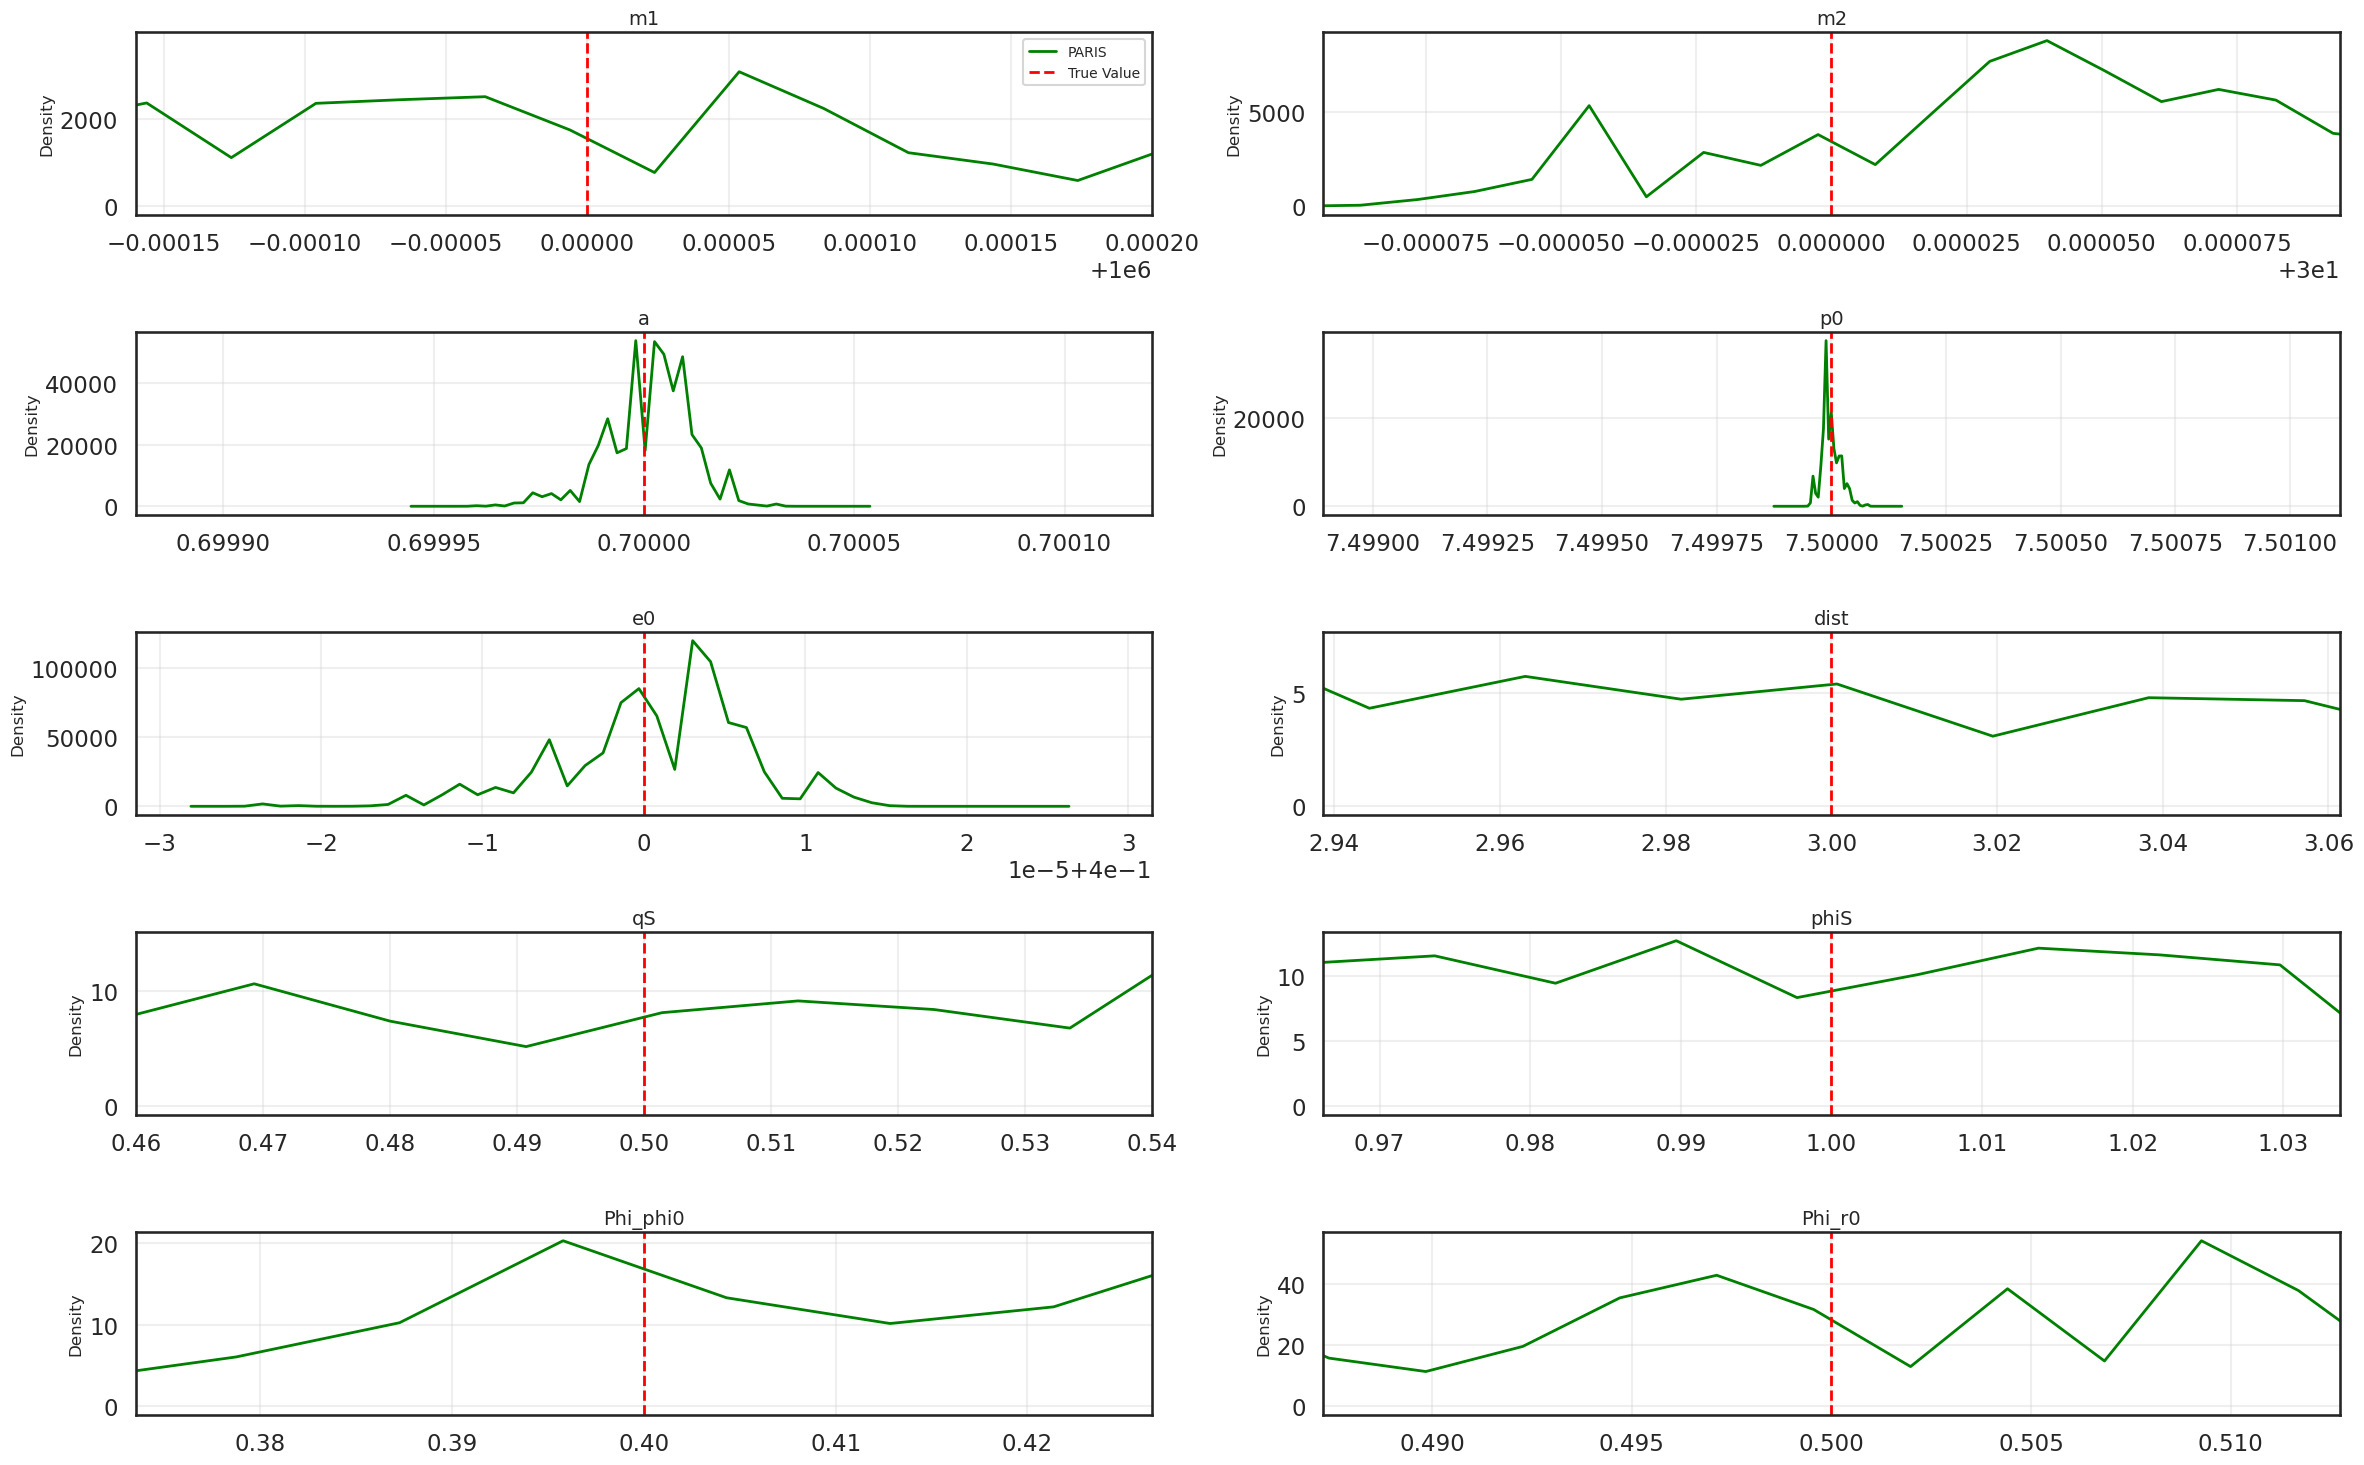

In [34]:
visualize_marginal_distributions(paris_sampler, './likelihoodtest_results/', true_values=param_true)


In [37]:
def compare_marginal(sampler, savepath, dynesty_file, true_values=None):
    """
    Create marginal distribution plots comparing PARIS and Dynesty 
results
    """
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        import pickle
    except ImportError:
        print("Required packages not available. Skipping visualization.")
        return

    print("\nCreating marginal distribution comparison plots...")

    # Get PARIS samples and weights
    paris_samples, paris_weights = sampler.get_samples_with_weights(flatten=True)
    ndim = paris_samples.shape[1]

    # Load Dynesty results
    try:
        with open(dynesty_file, 'rb') as f:
            dres = pickle.load(f)
        dynesty_samples, dynesty_weights = dres.samples, dres.importance_weights()
        # mean, cov = dyfunc.mean_and_cov(dynesty_samples, dynesty_weights)
        print(f"Loaded Dynesty results from {dynesty_file}")
    except Exception as e:
        print(f"Error loading Dynesty results: {e}")
        return

    # Parameter ranges from prior_transform function
    param_ranges = [
        [9.9999999984e+05, 1.0000000002e+06], # m1
        [2.9999906018e+01, 3.0000093982e+01], # m2
        [6.9987915412e-01, 7.0012084588e-01], # a
        [7.4988920111e+00, 7.5011079889e+00], # p0
        [3.9996851706e-01, 4.0003148294e-01], # e0
        [2.9386476938e+00, 3.0613523062e+00], # dist
        [4.5998172393e-01, 5.4001827607e-01], # qS
        [9.6625687330e-01, 1.0337431267e+00], # phiS
        [3.7348894300e-01, 4.2651105700e-01], # Phi_phi0
        [4.8726834297e-01, 5.1273165703e-01] # Phi_r0
    ]

    # Parameter names for titles
    param_names = ['m1', 'm2', 'a', 'p0', 'e0', 'dist', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']

    # Visualization parameters
    bin_num = 50
    decay = 3  # For exponential smoothing

    def exponential_smoothing(hist, decay=1.0):
        """Apply exponential smoothing to histogram."""
        smoothed = np.zeros_like(hist)
        for i in range(len(hist)):
            weights_exp = np.exp(-decay * np.abs(np.arange(len(hist)) -i))
            weights_exp /= np.sum(weights_exp)  # normalize
            smoothed[i] = np.sum(hist * weights_exp)
        return smoothed

    # Set up the plot
    sns.set(style="white", context="talk")

    # Create subplot grid
    n_rows = (ndim + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(24, 3*n_rows))

    # Flatten axes for easier indexing
    if ndim == 1:
        axes = [axes]
    elif ndim <= 2:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    for i in range(ndim):
        ax = axes[i]

        # PARIS samples
        paris_param_samples = paris_samples[:, i]
        paris_hist, bin_edges = np.histogram(paris_param_samples,bins=bin_num, weights=paris_weights, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        paris_hist = exponential_smoothing(paris_hist, decay=decay)
        ax.plot(bin_centers, paris_hist, color='green', linewidth=2,label='PARIS')

        # Dynesty samples
        if i < dynesty_samples.shape[1]:
            dynesty_param_samples = dynesty_samples[:, i]
            dynesty_hist, bin_edges = np.histogram(dynesty_param_samples,bins=bin_num, weights=dynesty_weights, density=True)
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            dynesty_hist = exponential_smoothing(dynesty_hist,decay=decay)
            ax.plot(bin_centers, dynesty_hist, color='blue', linewidth=2,label='Dynesty')

        # Add true value red line if provided
        if true_values is not None and i < len(true_values):
            ax.axvline(true_values[i], color='red', linestyle='--',linewidth=2,
                    label='True Value' if i == 0 else "")

        # Set x-axis limits to the prior ranges
        if i < len(param_ranges):
            ax.set_xlim(param_ranges[i][0], param_ranges[i][1])

        # Formatting with variable names
        param_name = param_names[i] if i < len(param_names) else f'Param {i+1}'
        ax.set_title(f'{param_name} Marginal Distribution', fontsize=14)
        ax.set_ylabel('Density', fontsize=12)
        ax.grid(True, alpha=0.3)

        # Add legend to first subplot
        if i == 0:
            ax.legend(fontsize=10, frameon=True)

    # Remove empty subplots if ndim is odd
    if ndim % 2 == 1 and ndim > 1:
        fig.delaxes(axes[-1])

    # Adjust layout
    plt.tight_layout()

    # Save the plot
    plot_filename = os.path.join(savepath,'compare_marginal.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Marginal distribution comparison plot saved to: {plot_filename}")

    # Show plot if in interactive environment
    try:
        plt.show()
    except:
        pass


Creating marginal distribution comparison plots...
Loaded Dynesty results from likelihoodtest2.pkl
Marginal distribution comparison plot saved to: ./likelihoodtest_results/compare_marginal.png


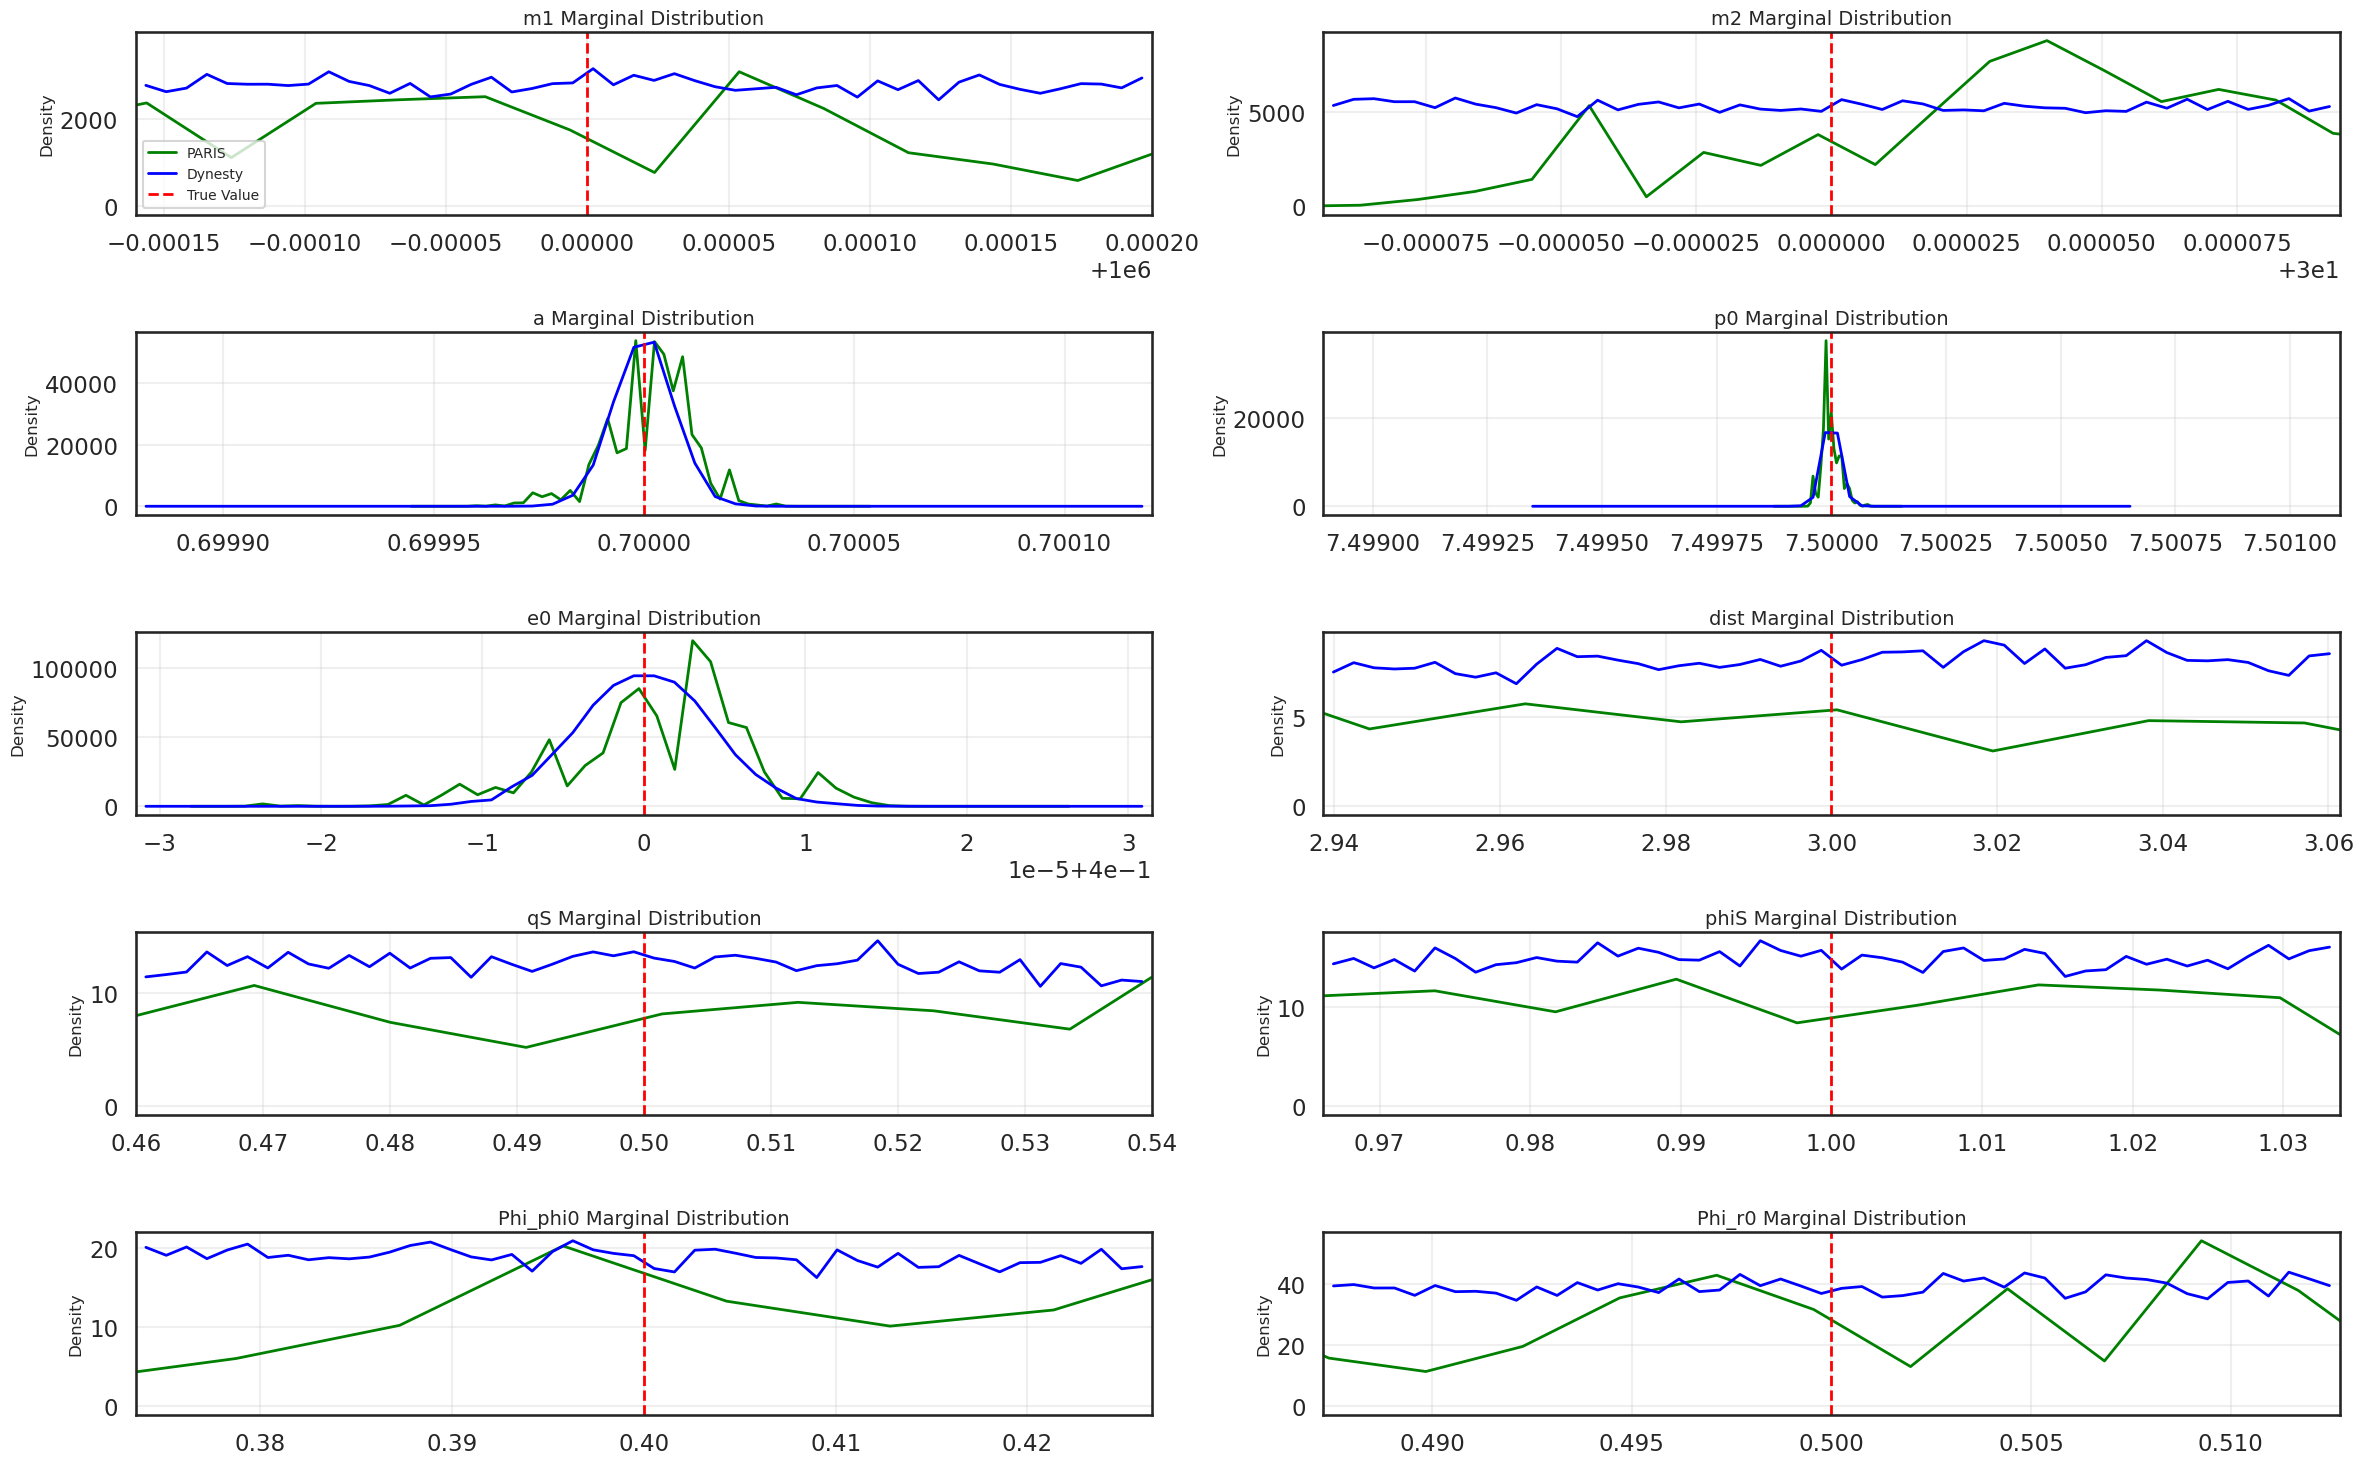

In [38]:
compare_marginal(paris_sampler, './likelihoodtest_results/', true_values=param_true, dynesty_file='likelihoodtest2.pkl')